<a href="https://colab.research.google.com/github/yisuznazi/juegosAjedrez/blob/main/ajedrez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


20.juegos de ajedrez


Distribución de ELO de jugadores blancos vs negros
¿Quién gana más, blancas o negras?
Partidas rated vs no rated

Análisis de aperturas columna eco y opening_name

¿Qué aperturas tienen mayor tasa de victoria?
¿Las aperturas más largas opening_ply favorecen a alguien?

Correlaciones interesantes

¿Más turnos = partidas más igualadas en ELO?
¿Diferencia de ELO predice el resultado?
¿El tiempo de control increment_code afecta quién gana?

Minería de texto columna moves

Movimientos más frecuentes en las primeras jugadas
Patrones de jugadas ganadoras



Predecir el ganador con white_elo, black_elo, opening_name, turns



In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix



In [66]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [67]:
df=pd.read_csv('games.csv')

In [68]:
df.head()

,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5


In [69]:
df.tail(
)

,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
20053,EfqH7VVH,True,1.499791e+12,1.499791e+12,24,resign,white,10+10,belcolt,1691,jamboger,1220,d4 f5 e3 e6 Nf3 Nf6 Nc3 b6 Be2 Bb7 O-O Be7 Ne5...,A80,Dutch Defense,2
20054,WSJDhbPl,True,1.499698e+12,1.499699e+12,82,mate,black,10+0,jamboger,1233,farrukhasomiddinov,1196,d4 d6 Bf4 e5 Bg3 Nf6 e3 exd4 exd4 d5 c3 Bd6 Bd...,A41,Queen's Pawn,2
20055,yrAas0Kj,True,1.499698e+12,1.499698e+12,35,mate,white,10+0,jamboger,1219,schaaksmurf3,1286,d4 d5 Bf4 Nc6 e3 Nf6 c3 e6 Nf3 Be7 Bd3 O-O Nbd...,D00,Queen's Pawn Game: Mason Attack,3
20056,b0v4tRyF,True,1.499696e+12,1.499697e+12,109,resign,white,10+0,marcodisogno,1360,jamboger,1227,e4 d6 d4 Nf6 e5 dxe5 dxe5 Qxd1+ Kxd1 Nd5 c4 Nb...,B07,Pirc Defense,4
20057,N8G2JHGG,True,1.499643e+12,1.499644e+12,78,mate,black,10+0,jamboger,1235,ffbob,1339,d4 d5 Bf4 Na6 e3 e6 c3 Nf6 Nf3 Bd7 Nbd2 b5 Bd3...,D00,Queen's Pawn Game: Mason Attack,3


In [70]:
df.dtypes

,0
id,object
rated,bool
created_at,float64
last_move_at,float64
turns,int64
victory_status,object
winner,object
increment_code,object
white_id,object
white_rating,int64


In [71]:
df.shape

(20058, 16)

In [72]:
df.isnull().sum()

,0
id,0
rated,0
created_at,0
last_move_at,0
turns,0
victory_status,0
winner,0
increment_code,0
white_id,0
white_rating,0


In [73]:
df.columns


Index(['id', 'rated', 'created_at', 'last_move_at', 'turns', 'victory_status',
       'winner', 'increment_code', 'white_id', 'white_rating', 'black_id',
       'black_rating', 'moves', 'opening_eco', 'opening_name', 'opening_ply'],
      dtype='object')

In [74]:
# Cuántas partidas gano cada uno agrupado por turnos
ganador_por_turnos = df.groupby(['winner', 'turns']).size().reset_index(name='cantidad_partidas')
print(ganador_por_turnos)

    winner  turns  cantidad_partidas
0    black      1                  2
1    black      2                108
2    black      3                 13
3    black      4                 36
4    black      5                  3
5    black      6                 26
6    black      7                  4
7    black      8                 32
8    black      9                  8
9    black     10                 44
10   black     11                 10
11   black     12                 56
12   black     13                 14
13   black     14                 71
14   black     15                 10
15   black     16                 81
16   black     17                 15
17   black     18                 84
18   black     19                 18
19   black     20                104
20   black     21                 21
21   black     22                 97
22   black     23                 20
23   black     24                114
24   black     25                 25
25   black     26                135
2

In [75]:
# Estadísticas descriptivas de turnos segun ganador
stats_turnos = df.groupby('winner')['turns'].describe()
print(stats_turnos)

          count       mean        std  min   25%   50%     75%    max
winner                                                               
black    9107.0  60.724388  32.369867  1.0  38.0  56.0   78.00  222.0
draw      950.0  86.157895  45.897861  2.0  50.0  89.0  116.75  259.0
white   10001.0  57.790221  32.193353  1.0  35.0  53.0   75.00  349.0


In [76]:
# Diferencia de ELO entre jugadores
df['diferencia_elo'] = abs(df['white_rating'] - df['black_rating'])

# ¿El que tiene mayor ELO suele ganar?
df['gano_mayor_elo'] = (
    ((df['white_rating'] > df['black_rating']) & (df['winner'] == 'white')) |
    ((df['black_rating'] > df['white_rating']) & (df['winner'] == 'black'))
)

print(df['gano_mayor_elo'].value_counts(normalize=True) * 100)

gano_mayor_elo
True     61.581414
False    38.418586
Name: proportion, dtype: float64


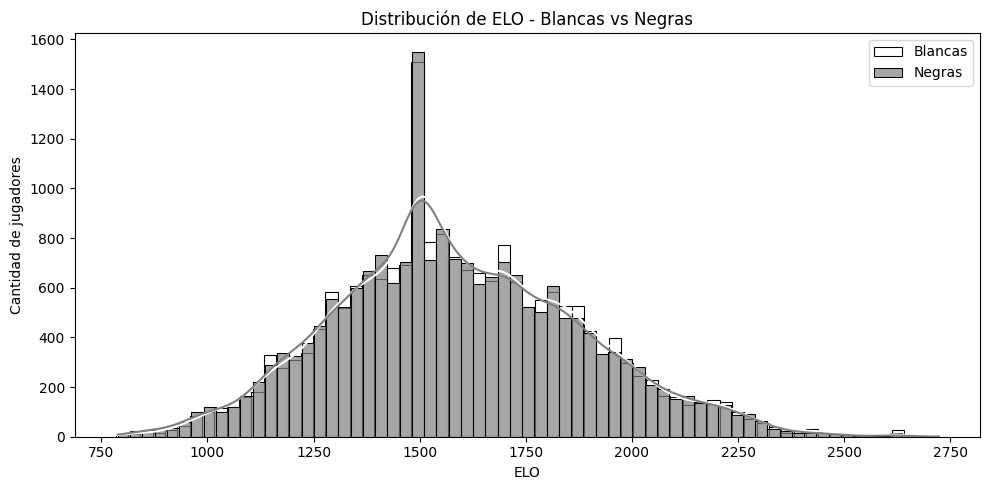

=== ELO Blancas ===
count    20058.000000
mean      1596.631868
std        291.253376
min        784.000000
25%       1398.000000
50%       1567.000000
75%       1793.000000
max       2700.000000
Name: white_rating, dtype: float64

=== ELO Negras ===
count    20058.000000
mean      1588.831987
std        291.036126
min        789.000000
25%       1391.000000
50%       1562.000000
75%       1784.000000
max       2723.000000
Name: black_rating, dtype: float64


In [77]:


# Distribución de ELO blancas vs negras
plt.figure(figsize=(10, 5))
sns.histplot(df['white_rating'], color='white', edgecolor='black', label='Blancas', kde=True, alpha=0.7)
sns.histplot(df['black_rating'], color='gray', edgecolor='black', label='Negras', kde=True, alpha=0.7)

plt.title("Distribución de ELO - Blancas vs Negras")
plt.xlabel("ELO")
plt.ylabel("Cantidad de jugadores")
plt.legend()
plt.tight_layout()
plt.show()

# Estadísticas descriptivas
print("=== ELO Blancas ===")
print(df['white_rating'].describe())
print("\n=== ELO Negras ===")
print(df['black_rating'].describe())

In [78]:
#mucha gente esta en los 1500 de elo, mayor miente son jugadores de negras los que han ganado partidas en eta categoria

=== Conteo de victorias ===
winner
white    10001
black     9107
draw       950
Name: count, dtype: int64

=== Porcentaje ===
winner
white    49.86
black    45.40
draw      4.74
Name: proportion, dtype: float64


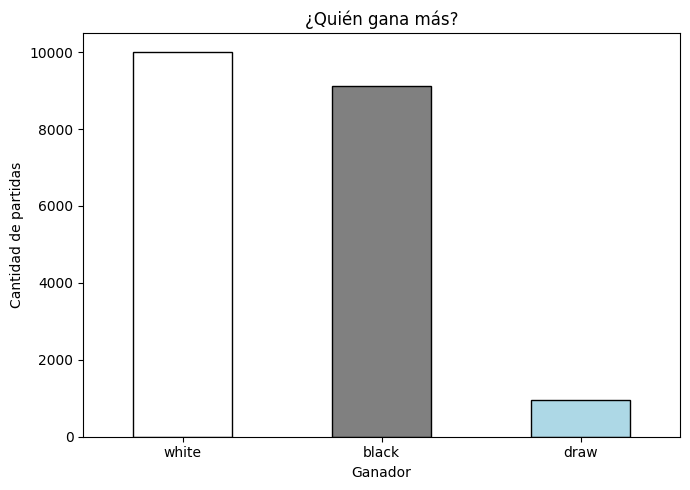

In [79]:
# Conteo de victorias
victorias = df['winner'].value_counts()
porcentaje = df['winner'].value_counts(normalize=True) * 100

print("=== Conteo de victorias ===")
print(victorias)
print("\n=== Porcentaje ===")
print(porcentaje.round(2))

# Gráfico
plt.figure(figsize=(7, 5))
colores = ['white', 'gray', 'lightblue']
victorias.plot(kind='bar', color=colores, edgecolor='black')

plt.title("¿Quién gana más?")
plt.xlabel("Ganador")
plt.ylabel("Cantidad de partidas")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

=== Partidas Rated vs No Rated ===
rated
True     16155
False     3903
Name: count, dtype: int64


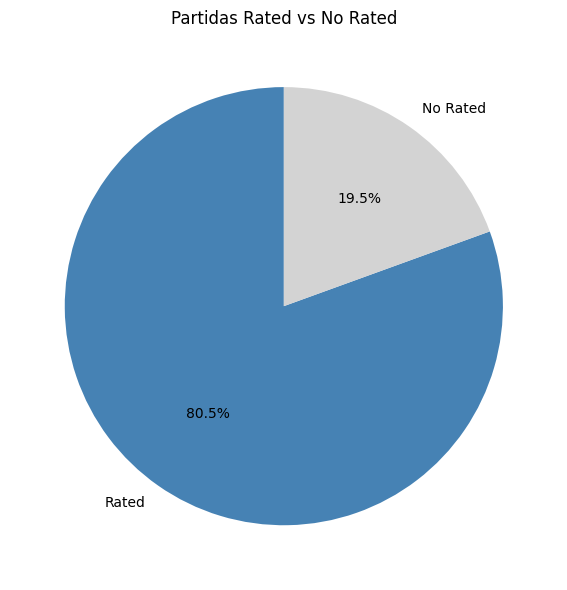


=== Ganador según tipo de partida ===
rated  winner
False  white     49.9
       black     44.1
       draw       5.9
True   white     49.8
       black     45.7
       draw       4.5
Name: proportion, dtype: float64


In [80]:
# Conteo
rated_count = df['rated'].value_counts()
print("=== Partidas Rated vs No Rated ===")
print(rated_count)

# Gráfico de torta
plt.figure(figsize=(6, 6))
plt.pie(
    rated_count,
    labels=['Rated', 'No Rated'],
    autopct='%1.1f%%',
    colors=['steelblue', 'lightgray'],
    startangle=90
)
plt.title("Partidas Rated vs No Rated")
plt.tight_layout()
plt.show()

# ¿Influye el rated en quién gana?
print("\n=== Ganador según tipo de partida ===")
print(df.groupby('rated')['winner'].value_counts(normalize=True).round(3) * 100)

In [81]:
#mayor mente ganarian los quetienen elo

=== Top 10 aperturas más jugadas ===
opening_name
Van't Kruijs Opening                             368
Sicilian Defense                                 358
Sicilian Defense: Bowdler Attack                 296
French Defense: Knight Variation                 271
Scotch Game                                      271
Scandinavian Defense: Mieses-Kotroc Variation    259
Queen's Pawn Game: Mason Attack                  232
Queen's Pawn Game: Chigorin Variation            229
Scandinavian Defense                             223
Horwitz Defense                                  209
Name: count, dtype: int64

=== Tasa de victoria por apertura (%) ===
winner                                         black  draw  white
opening_name                                                     
Caro-Kann Defense                              41.71  3.52  54.77
French Defense: Knight Variation               44.65  5.54  49.82
Horwitz Defense                                44.98  2.39  52.63
Indian Game          

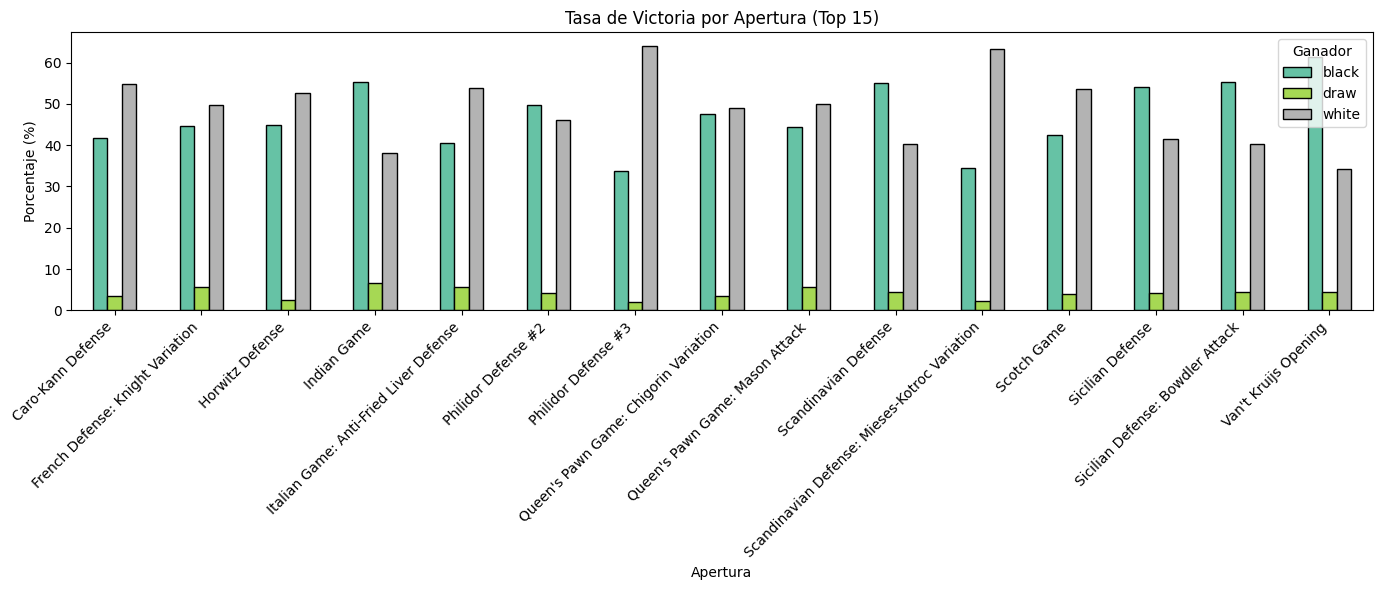

In [82]:
# Top 10 aperturas más jugadas
top_aperturas = df['opening_name'].value_counts().head(10)
print("=== Top 10 aperturas más jugadas ===")
print(top_aperturas)

# Tasa de victoria por apertura (top 16)
top15 = df['opening_name'].value_counts().head(15).index

tasa_victoria = (
    df[df['opening_name'].isin(top15)]
    .groupby('opening_name')['winner']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .unstack()
)

print("\n=== Tasa de victoria por apertura (%) ===")
print(tasa_victoria)

# Gráfico
tasa_victoria.plot(kind='bar', figsize=(14, 6), colormap='Set2', edgecolor='black')
plt.title("Tasa de Victoria por Apertura (Top 15)")
plt.xlabel("Apertura")
plt.ylabel("Porcentaje (%)")
plt.xticks(rotation=45, ha='right')
plt.legend(title='Ganador')
plt.tight_layout()
plt.show()

9 victorias blancas y 6 victorias negras,

=== Promedio de opening_ply por ganador ===
winner
black    4.74
draw     5.06
white    4.86
Name: opening_ply, dtype: float64


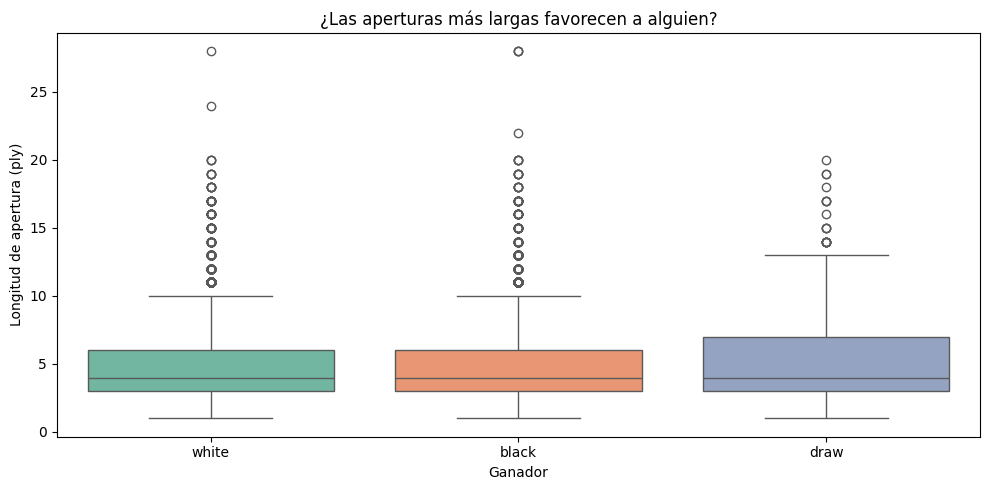


Correlación opening_ply con winner_encoded: 0.0207


In [83]:
# Promedio de opening_ply por ganador
print("=== Promedio de opening_ply por ganador ===")
print(df.groupby('winner')['opening_ply'].mean().round(2))


# Distribución de opening_ply por ganador
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df,
    x='winner',
    y='opening_ply',
    hue='winner',
    palette='Set2',
    legend=False
    )
plt.title("¿Las aperturas más largas favorecen a alguien?")
plt.xlabel("Ganador")
plt.ylabel("Longitud de apertura (ply)")
plt.tight_layout()
plt.show()

# Correlación opening_ply con winner_encoded
df['winner_encoded'] = df['winner'].map({'white': 1, 'black': -1, 'draw': 0})
correlacion = df['opening_ply'].corr(df['winner_encoded'])
print(f"\nCorrelación opening_ply con winner_encoded: {correlacion:.4f}")

In [84]:
#la longitud de la partida no favorece a ninguno, hace que el empate sea mas probable

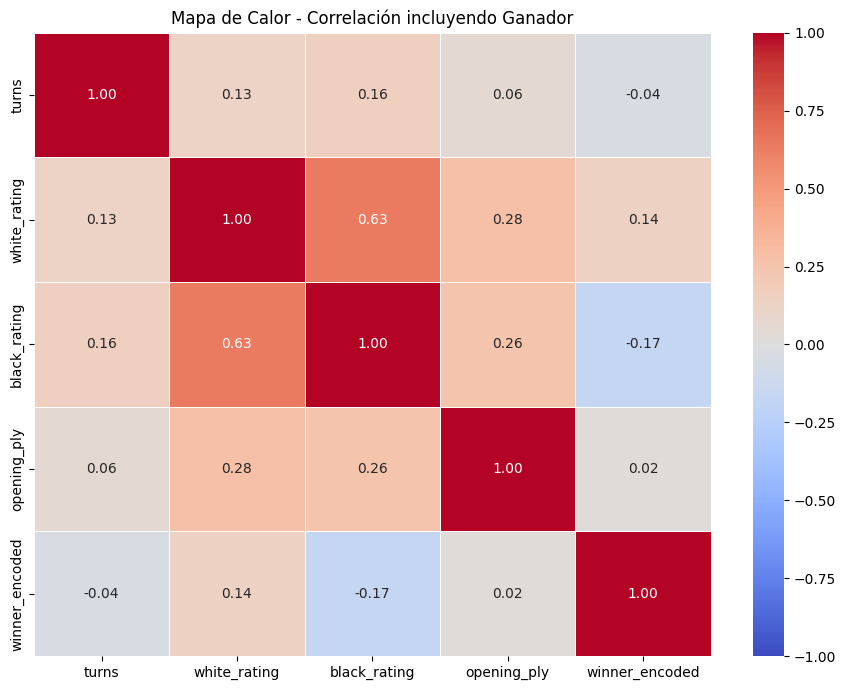

In [85]:
#'white_rating', 'black_rating' son: los rangos de elo, desde 800 a 3600 por ejemplo
#opening_ply es cantidad de turnos de inicio
# Codificar 'winner' como número para incluirlo
df['winner_encoded'] = df['winner'].map({'white': 1, 'black': -1, 'draw': 0})

columnas = df[['turns', 'white_rating', 'black_rating', 'opening_ply', 'winner_encoded']]

correlacion = columnas.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5
)

plt.title("Mapa de Calor - Correlación incluyendo Ganador")
plt.tight_layout()
plt.show()

elo=puntos/clasificacion

Lichess empareja jugadores de nivel similar (0.63)
Los jugadores de mayor nivel conocen aperturas más largas y elaboradas(white_raring con mas elo =028) y (black_raring con menos elo =026)
los que juegan con las fichas negras usan mas turnos
las fichas negras con mas propensas a perder


=== Top 10 primeras jugadas — BLANCAS ===
moves
e4     12598
d4      4522
Nf3      725
c4       716
e3       416
g3       186
b3       173
f4       166
d3       131
Nc3       99
Name: count, dtype: int64

=== Top 10 primeras jugadas — NEGRAS ===
moves
e5     6988
d5     3667
c5     2883
e6     2083
Nf6    1693
c6      734
d6      543
Nc6     392
g6      387
b6      286
Name: count, dtype: int64


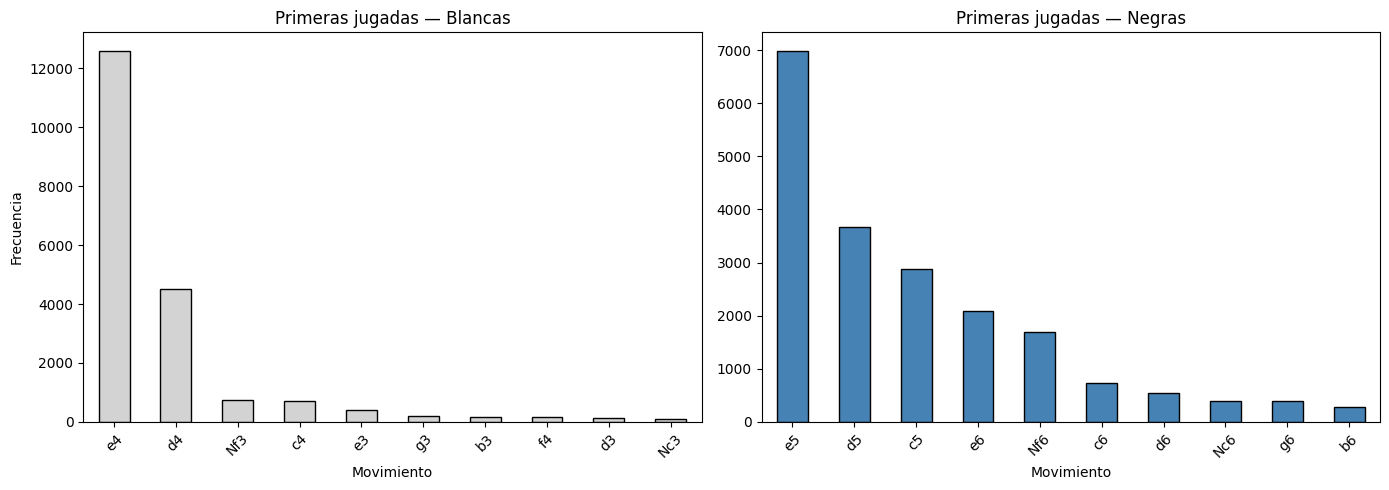

In [86]:


# Extraer solo los primeros N movimientos de cada partida
def primeros_movimientos(moves_series, n=1):
    """Extrae el movimiento número n de cada partida (0=primero, 1=segundo...)"""
    return moves_series.apply(lambda x: x.split()[n] if len(x.split()) > n else None)

# Primer movimiento de blancas (jugada 0)
primer_mov_blancas = primeros_movimientos(df['moves'], 0)
# Primer movimiento de negras (jugada 1)
primer_mov_negras  = primeros_movimientos(df['moves'], 1)

# Top 10 más frecuentes
top_blancas = primer_mov_blancas.value_counts().head(10)
top_negras  = primer_mov_negras.value_counts().head(10)

print("=== Top 10 primeras jugadas — BLANCAS ===")
print(top_blancas)
print("\n=== Top 10 primeras jugadas — NEGRAS ===")
print(top_negras)

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_blancas.plot(kind='bar', ax=axes[0], color='lightgray', edgecolor='black')
axes[0].set_title("Primeras jugadas — Blancas")
axes[0].set_xlabel("Movimiento")
axes[0].set_ylabel("Frecuencia")
axes[0].tick_params(axis='x', rotation=45)

top_negras.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title("Primeras jugadas — Negras")
axes[1].set_xlabel("Movimiento")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

=== Top movimientos de BLANCAS cuando GANAN ===
  Nf3: 9558
  e4: 8186
  d4: 7610
  Nc3: 7174
  O-O: 6191
  c4: 3806
  Bc4: 3200
  h3: 3073
  c3: 2992
  Bd3: 2621

=== Top movimientos de NEGRAS cuando GANAN ===
  Nf6: 7944
  Nc6: 6717
  d5: 5659
  e5: 5539
  O-O: 5462
  c5: 4160
  e6: 4015
  d6: 3623
  a6: 2998
  h6: 2917


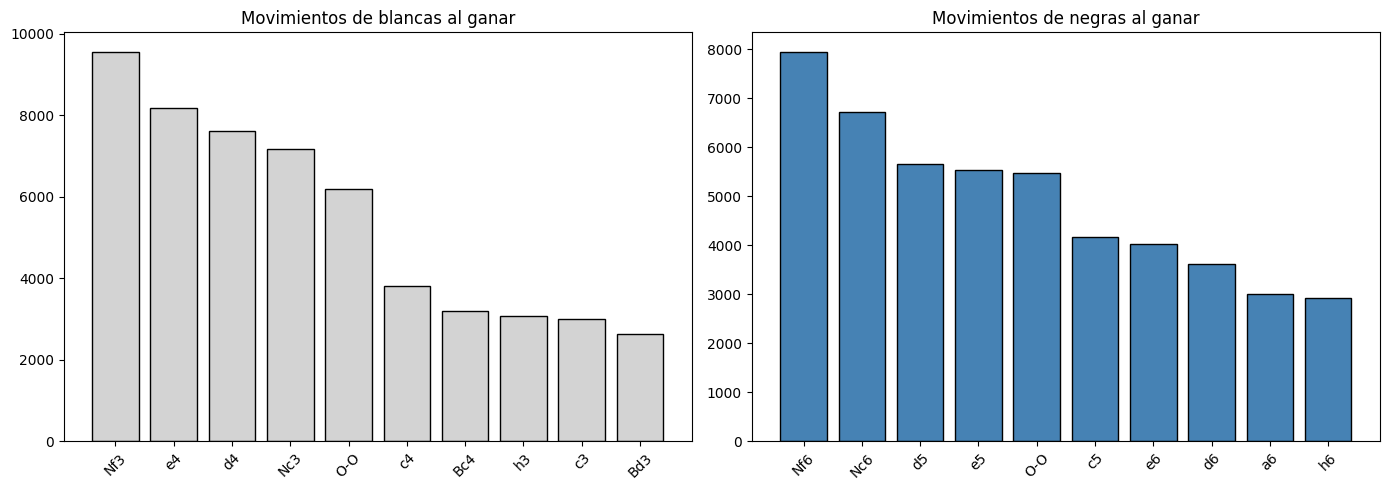

In [87]:
# Separar partidas por ganador
moves_white_wins = df[df['winner'] == 'white']['moves']
moves_black_wins = df[df['winner'] == 'black']['moves']

# Función: extraer todos los movimientos de un lado (pares=blancas, impares=negras)
def movimientos_de_lado(moves_series, lado='blancas', top_n=10):
    todos = []
    for partida in moves_series:
        movs = partida.split()
        if lado == 'blancas':
            todos.extend(movs[::2])   # índices pares
        else:
            todos.extend(movs[1::2])  # índices impares
    return Counter(todos).most_common(top_n)

# Top movimientos cuando ganan blancas
top_blancas_gana = movimientos_de_lado(moves_white_wins, 'blancas')
top_negras_gana  = movimientos_de_lado(moves_black_wins, 'negras')

print("=== Top movimientos de BLANCAS cuando GANAN ===")
for mov, freq in top_blancas_gana:
    print(f"  {mov}: {freq}")

print("\n=== Top movimientos de NEGRAS cuando GANAN ===")
for mov, freq in top_negras_gana:
    print(f"  {mov}: {freq}")

# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

movs_b, freqs_b = zip(*top_blancas_gana)
movs_n, freqs_n = zip(*top_negras_gana)

axes[0].bar(movs_b, freqs_b, color='lightgray', edgecolor='black')
axes[0].set_title("Movimientos de blancas al ganar")
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(movs_n, freqs_n, color='steelblue', edgecolor='black')
axes[1].set_title("Movimientos de negras al ganar")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Entrenamiento: 16046 partidas
Prueba:        4012 partidas

=== Reporte de clasificación ===
              precision    recall  f1-score   support

       black       0.66      0.67      0.67      1816
        draw       0.59      0.10      0.17       192
       white       0.69      0.74      0.71      2004

    accuracy                           0.68      4012
   macro avg       0.65      0.50      0.52      4012
weighted avg       0.67      0.68      0.66      4012



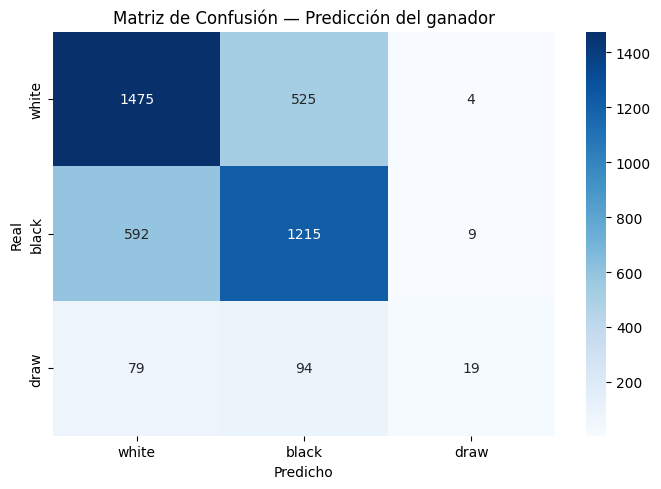


=== Importancia de variables ===
white_rating       0.270507
black_rating       0.270088
turns              0.246845
opening_encoded    0.212561
dtype: float64


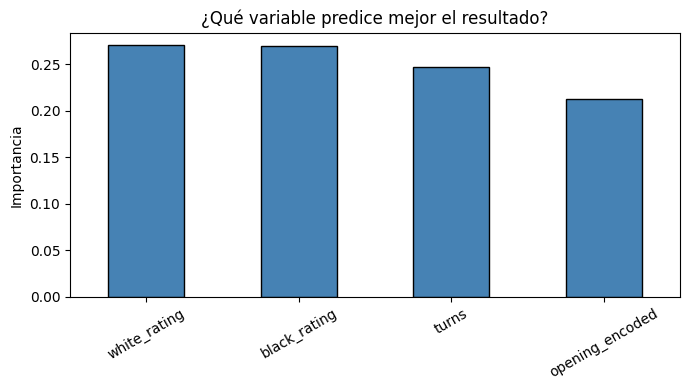

In [88]:


# ── Preparar datos ──────────────────────────────────────────
# Codificar opening_name como número
le = LabelEncoder()
df['opening_encoded'] = le.fit_transform(df['opening_name'])

# Features y target
X = df[['white_rating', 'black_rating', 'opening_encoded', 'turns']]
y = df['winner']

# Eliminar filas con nulos
X = X.dropna()
y = y[X.index]

# División entrenamiento / prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Entrenamiento: {len(X_train)} partidas")
print(f"Prueba:        {len(X_test)} partidas")

# ── Modelo ──────────────────────────────────────────────────
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

# ── Evaluación ──────────────────────────────────────────────
y_pred = modelo.predict(X_test)

print("\n=== Reporte de clasificación ===")
print(classification_report(y_test, y_pred))

# ── Matriz de confusión ─────────────────────────────────────
cm = confusion_matrix(y_test, y_pred, labels=['white', 'black', 'draw'])

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['white', 'black', 'draw'],
    yticklabels=['white', 'black', 'draw']
)
plt.title("Matriz de Confusión — Predicción del ganador")
plt.ylabel("Real")
plt.xlabel("Predicho")
plt.tight_layout()
plt.show()

# ── Importancia de variables ─────────────────────────────────
importancias = pd.Series(
    modelo.feature_importances_,
    index=['white_rating', 'black_rating', 'opening_encoded', 'turns']
).sort_values(ascending=False)

print("\n=== Importancia de variables ===")
print(importancias)

importancias.plot(kind='bar', color='steelblue', edgecolor='black', figsize=(7, 4))
plt.title("¿Qué variable predice mejor el resultado?")
plt.ylabel("Importancia")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
#Se espera que white_rating y black_rating sean los más relevantes, ya que la diferencia de habilidad es el factor más determinante